# Rx PD Model - Dataset Exploration

This notebook explores the Lending Default datasets (training and holdout).

In [1]:
# !pip install optbinning probatus shap

In [2]:
from google.colab import drive
import os

# Try to unmount if already mounted to avoid stale states
if os.path.exists('/content/drive/My Drive'):
    try:
        drive.flush_and_unmount()
        print('Drive unmounted successfully.')
    except Exception as e:
        print(f'Error unmounting drive: {e}')

try:
    drive.mount('/content/drive', force_remount=True)
    print('Drive mounted successfully.')
except ValueError as e:
    print(f'Google Drive mount failed: {e}. Please ensure you complete the authentication process in the pop-up window.')

# Define the path to your folder
folder_path = '/content/drive/My Drive/Colab Notebooks/RX_PD_Model/'

# Read the CSV files
# Ensure these files exist in your Google Drive at the specified path
import pandas as pd
df_train_tx = pd.read_csv(folder_path + 'Lending_default_train_tx.csv')
df_train_acc = pd.read_csv(folder_path + 'Lending_default_train_account.csv')
df_train_label = pd.read_csv(folder_path + 'Lending_default_train_label.csv')
df_holdout_tx = pd.read_csv(folder_path + 'Lending_default_holdout_tx.csv')
df_holdout_acc = pd.read_csv(folder_path + 'Lending_default_holdout_account.csv')

# Verify the data loaded
print("Train TX shape:", df_train_tx.shape)
print("Train Account shape:", df_train_acc.shape)
print("Train Label shape:", df_train_label.shape)
print("Holdout TX shape:", df_holdout_tx.shape)
print("Holdout Account shape:", df_holdout_acc.shape)

Drive unmounted successfully.
Mounted at /content/drive
Drive mounted successfully.
Train TX shape: (3510679, 5)
Train Account shape: (10812, 5)
Train Label shape: (10812, 3)
Holdout TX shape: (1471016, 5)
Holdout Account shape: (4514, 5)


In [3]:
import pandas as pd
import numpy as np
import random

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

import matplotlib.pyplot as plt #For plotting graphs
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, \
accuracy_score, classification_report, confusion_matrix, mean_squared_error, \
balanced_accuracy_score,roc_curve,auc

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Recursive Feature Elimination
from probatus.feature_elimination import ShapRFECV

import shap
shap.initjs()

from optbinning import OptimalBinning

import warnings
warnings.filterwarnings("ignore")

In [4]:
def check_missing(data):
    MissTotal = data.isnull().sum().sort_values(ascending=False)
    percent = round((data.isnull().sum()/list(data.shape)[0]*100),2).sort_values(ascending=False)
    count = data.isnull().count().sort_values(ascending=False)
    missing_data = pd.concat([MissTotal, percent, count], axis=1, keys=['MissingTotal', 'MissingPercent', 'Total'])
    # print(missing_data[missing_data['MissingPercent']>0].head(10))
    print(missing_data.head(10))

def performance_metrics(y_true, y_pred, threshold=0.5):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    # y_pred_bin = np.round(y_pred)
    y_pred_bin = [0 if y < threshold else 1 for y in y_pred]
    d={}
    d['accuracy'] = accuracy_score(y_true, y_pred_bin)
    d['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred_bin)
    d['precision'] = precision_score(y_true, y_pred_bin)
    d['recall'] = recall_score(y_true, y_pred_bin)
    d['RMSE'] = mean_squared_error(y_true, y_pred, squared=False)
    cm = confusion_matrix(y_true, y_pred_bin)
    cm = pd.DataFrame(cm, index=[['Observed','Observed'],['False','True']],\
                      columns=[['Predicted','Predicted'],['False','True']])
    text = 'Performance Metrics\n'
    p = 20
    for i,j in d.items():
        text += '\n{}{} = {:.3f}'.format(i.title(),' '*(p-len(i)),j)
    print(text,'\n\nConfusion Matrix')
    return print(cm)

def plot_auc2(ax, y_train, y_train_pred, y_test, y_test_pred, th=0.5):

    y_train_pred_labels = (y_train_pred>th).astype(int)
    y_test_pred_labels  = (y_test_pred>th).astype(int)

    fpr_train, tpr_train, _ = roc_curve(y_train,y_train_pred)
    ks_train = max(tpr_train-fpr_train)
    roc_auc_train = auc(fpr_train, tpr_train)
    acc_train = accuracy_score(y_train, y_train_pred_labels)

    fpr_test, tpr_test, _ = roc_curve(y_test,y_test_pred)
    ks_test = max(tpr_test-fpr_test)
    roc_auc_test = auc(fpr_test, tpr_test)
    acc_test = accuracy_score(y_test, y_test_pred_labels)

    ax.plot(fpr_train, tpr_train,color="blue")
    ax.plot(fpr_test, tpr_test,color="red")

    ax.plot([0, 1], [0, 1], 'k--')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1-Specificity) = FP/(FP+TN)')
    ax.set_ylabel('True Positive Rate (Sensitivity) = TP/(TP+FN)')
    ax.set_title('ROC curve')

    train_text = 'Train KS = {:.2f}, AUC = {:.2f}'.format(ks_train, roc_auc_train)
    test_text = 'Test KS = {:.2f}, AUC = {:.2f}'.format(ks_test, roc_auc_test)
    no_skill_text = 'no skill'
    ax.legend([train_text, test_text, no_skill_text])

def exp_vs_act(df,score,target,title=None):

    #print(df.info())
    orig_feature = score

    #CREATE THE SUMMARY TABLE
    if str(df[orig_feature].dtype) !='object':
        grp_range = 'grp_' + score
        df[grp_range] = pd.qcut(df[score], q=10, labels=None, retbins = False, precision=4, duplicates = 'raise')
        df['grp_num'] = (pd.qcut(df[score], q=10, labels=False, retbins = False, precision=4, duplicates = 'raise')+1).astype(str).str.zfill(2)
        df['grp'] = df['grp_num'].astype(str) + ' ' +df[grp_range].astype(str)
        score = 'grp'

    non_events = pd.DataFrame(df[df[target]==0].groupby([score],dropna=False)[target].count()).rename(columns={target: 'non_events'})
    non_events_total = df[df[target]==0].groupby([target],dropna=False)[target].count()
    events = pd.DataFrame(df[df[target]==1].groupby([score],dropna=False)[target].count()).rename(columns={target: 'events'})
    events_total = df[df[target]==1].groupby([target],dropna=False)[target].count()
    grand_total = df[target].count()
    result = pd.merge(non_events, events, how="left",on=score)

    if str(df[orig_feature].dtype) !='object':
        pred_events = round(pd.DataFrame(df.groupby([score],dropna=False)[orig_feature].sum()),1).rename(columns={orig_feature: 'pred_events'})
        result = pd.merge(result, pred_events, how="left",on=score)

    result['total'] = result['non_events'] + result['events']
    result['act_event_rate'] = round(result['events']/result['total'],3)
    if str(df[orig_feature].dtype) !='object':
        result['pred_event_rate'] = round(result['pred_events']/result['total'],3)
    result['% event dist'] = result['events']/(events_total.values)
    result['% non-event dist'] = result['non_events']/(non_events_total.values)
    result['% total dist'] = round(result['total']/grand_total*100,1)
    cond = ((result['% non-event dist']==0) | (result['% event dist'] ==0)) # Dont calculate WOE and IV if the bin has missing values of events and/or non-events
    result.loc[~cond,"WoE"] = np.log(result.loc[~cond,"% non-event dist"]/result.loc[~cond,"% event dist"])
    result.loc[~cond,"IV"] = (result['% non-event dist']-result['% event dist'])*result['WoE']

    # Calculate IV
    IV = round(result.IV.sum(),6)
    #print('Information Value of',"'"+score+"'",'is', IV)

    #round off the decimal places for better display
    result['% event dist'] = round(result['% event dist']*100,1)
    result['% non-event dist'] = round(result['% non-event dist']*100,1)
    result['WoE'] = round(result['WoE'],2)
    result['IV'] = round(result['IV'],2)

    # convert index (score) to column
    result.reset_index(inplace=True)

    # Replace nan with Missing
    result[score]=result[score].replace(np.nan, 'Missing', regex=True)

    ax = result.plot(x='grp', y=['act_event_rate','pred_event_rate'],marker="*",title=title)
    ax.set_xticks(range(len(result)))
    p = ax.set_xticklabels([item for item in result.grp.tolist()],rotation=45)
    return result

## Training Dataset

In [5]:
# Load training data

print('=' * 80)
print('TRAINING ACCOUNT DATA')
print('=' * 80)
print(f'Shape: {df_train_acc.shape}')
print(f'\nColumns: {list(df_train_acc.columns)}')
print(f'\nData Types:\n{df_train_acc.dtypes}')
print(f'\nMissing Values:\n{df_train_acc.isnull().sum()}')
print(f'\nFirst 5 rows:')
print(df_train_acc.head())
print(f'\nBasic Statistics:')
print(df_train_acc.describe())

TRAINING ACCOUNT DATA
Shape: (10812, 5)

Columns: ['Unnamed: 0', 'Restaurant_ID', 'Ownership_type', 'Restaurant_catagory', 'Market_segment']

Data Types:
Unnamed: 0              int64
Restaurant_ID          object
Ownership_type         object
Restaurant_catagory    object
Market_segment         object
dtype: object

Missing Values:
Unnamed: 0               0
Restaurant_ID            0
Ownership_type         220
Restaurant_catagory      3
Market_segment           0
dtype: int64

First 5 rows:
   Unnamed: 0                         Restaurant_ID Ownership_type  \
0           0  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5    Partnership   
1           1  2c35efdf-410f-4188-bfe9-9777a737a107    Partnership   
2           2  6fa519c2-e88c-4012-a981-4e4fa55be951    Corporation   
3           3  541dd2c4-f612-4d28-9fae-7e28c9ee8584            LLC   
4           4  f010f8ec-7440-4676-b7b3-ed3f4e27baf4    Corporation   

  Restaurant_catagory Market_segment  
0   QSR - Fast Casual            SMB  
1  

In [6]:
print('=' * 80)
print('TRAINING TRANSACTION DATA')
print('=' * 80)
print(f'Shape: {df_train_tx.shape}')
print(f'\nColumns: {list(df_train_tx.columns)}')
print(f'\nData Types:\n{df_train_tx.dtypes}')
print(f'\nMissing Values:\n{df_train_tx.isnull().sum()}')
print(f'\nFirst 5 rows:')
print(df_train_tx.head())
print(f'\nBasic Statistics:')
print(df_train_tx.describe())

TRAINING TRANSACTION DATA
Shape: (3510679, 5)

Columns: ['Unnamed: 0', 'Restaurant_ID', 'Tx_date', 'processing_volume', 'Tx_hours']

Data Types:
Unnamed: 0             int64
Restaurant_ID         object
Tx_date               object
processing_volume    float64
Tx_hours             float64
dtype: object

Missing Values:
Unnamed: 0           0
Restaurant_ID        0
Tx_date              0
processing_volume    0
Tx_hours             0
dtype: int64

First 5 rows:
   Unnamed: 0                         Restaurant_ID     Tx_date  \
0           0  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5  2021-02-02   
1           1  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5  2021-02-03   
2           2  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5  2021-02-04   
3           3  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5  2021-02-05   
4           4  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5  2021-02-06   

   processing_volume  Tx_hours  
0            3778.49      12.0  
1            4456.12      14.0  
2            4868.75      12.0  
3

In [7]:
print('=' * 80)
print('TRAINING LABEL DATA')
print('=' * 80)
print(f'Shape: {df_train_label.shape}')
print(f'\nColumns: {list(df_train_label.columns)}')
print(f'\nData Types:\n{df_train_label.dtypes}')
print(f'\nMissing Values:\n{df_train_label.isnull().sum()}')
print(f'\nFirst 5 rows:')
print(df_train_label.head())
print(f'\nLabel Distribution:')
print(df_train_label.iloc[:, -1].value_counts())

TRAINING LABEL DATA
Shape: (10812, 3)

Columns: ['Unnamed: 0', 'Restaurant_ID', 'loan_default']

Data Types:
Unnamed: 0         int64
Restaurant_ID     object
loan_default     float64
dtype: object

Missing Values:
Unnamed: 0       0
Restaurant_ID    0
loan_default     0
dtype: int64

First 5 rows:
   Unnamed: 0                         Restaurant_ID  loan_default
0           0  cc3c8fb4-84c6-49c8-bcc7-6d23c626dad5           0.0
1           1  2c35efdf-410f-4188-bfe9-9777a737a107           0.0
2           2  6fa519c2-e88c-4012-a981-4e4fa55be951           1.0
3           3  541dd2c4-f612-4d28-9fae-7e28c9ee8584           0.0
4           4  f010f8ec-7440-4676-b7b3-ed3f4e27baf4           0.0

Label Distribution:
loan_default
0.0    9787
1.0    1025
Name: count, dtype: int64


## Holdout Dataset

In [8]:
# Load holdout data

print('=' * 80)
print('HOLDOUT ACCOUNT DATA')
print('=' * 80)
print(f'Shape: {df_holdout_acc.shape}')
print(f'\nColumns: {list(df_holdout_acc.columns)}')
print(f'\nData Types:\n{df_holdout_acc.dtypes}')
print(f'\nMissing Values:\n{df_holdout_acc.isnull().sum()}')
print(f'\nFirst 5 rows:')
print(df_holdout_acc.head())
print(f'\nBasic Statistics:')
print(df_holdout_acc.describe())

HOLDOUT ACCOUNT DATA
Shape: (4514, 5)

Columns: ['Unnamed: 0', 'Restaurant_ID', 'Ownership_type', 'Restaurant_catagory', 'Market_segment']

Data Types:
Unnamed: 0              int64
Restaurant_ID          object
Ownership_type         object
Restaurant_catagory    object
Market_segment         object
dtype: object

Missing Values:
Unnamed: 0              0
Restaurant_ID           0
Ownership_type         72
Restaurant_catagory     3
Market_segment          0
dtype: int64

First 5 rows:
   Unnamed: 0                         Restaurant_ID       Ownership_type  \
0           0  7ae540d4-fd25-488e-b081-800847db321e  Sole Proprietorship   
1           1  44c79166-f2af-47f8-9b39-6708174a6328                  LLC   
2           2  851df45d-4ef0-482d-b13f-84ce70cd8ab9  Sole Proprietorship   
3           3  ab873be0-28c6-460d-a84a-8381a34eba53                  LLC   
4           4  c4f4aea8-fff8-439b-8a1a-f9a6d8d4a4ad  Sole Proprietorship   

   Restaurant_catagory Market_segment  
0  FSR - Cas

In [9]:
print('=' * 80)
print('HOLDOUT TRANSACTION DATA')
print('=' * 80)
print(f'Shape: {df_holdout_tx.shape}')
print(f'\nColumns: {list(df_holdout_tx.columns)}')
print(f'\nData Types:\n{df_holdout_tx.dtypes}')
print(f'\nMissing Values:\n{df_holdout_tx.isnull().sum()}')
print(f'\nFirst 5 rows:')
print(df_holdout_tx.head())
print(f'\nBasic Statistics:')
print(df_holdout_tx.describe())

HOLDOUT TRANSACTION DATA
Shape: (1471016, 5)

Columns: ['Unnamed: 0', 'Restaurant_ID', 'Tx_date', 'processing_volume', 'Tx_hours']

Data Types:
Unnamed: 0             int64
Restaurant_ID         object
Tx_date               object
processing_volume    float64
Tx_hours             float64
dtype: object

Missing Values:
Unnamed: 0           0
Restaurant_ID        0
Tx_date              0
processing_volume    0
Tx_hours             0
dtype: int64

First 5 rows:
   Unnamed: 0                         Restaurant_ID     Tx_date  \
0           0  7ae540d4-fd25-488e-b081-800847db321e  2021-07-02   
1           1  7ae540d4-fd25-488e-b081-800847db321e  2021-07-03   
2           2  7ae540d4-fd25-488e-b081-800847db321e  2021-07-04   
3           3  7ae540d4-fd25-488e-b081-800847db321e  2021-07-05   
4           4  7ae540d4-fd25-488e-b081-800847db321e  2021-07-06   

   processing_volume  Tx_hours  
0            3223.37      16.0  
1            2555.51      16.0  
2            2774.95      14.0  
3 

## Dataset Summary

In [10]:
print('=' * 80)
print('DATASET SUMMARY')
print('=' * 80)
print(f'\nTraining Set:')
print(f'  - Accounts: {len(df_train_acc)}')
print(f'  - Transactions: {len(df_train_tx)}')
print(f'  - Labels: {len(df_train_label)}')

print(f'\nHoldout Set:')
print(f'  - Accounts: {len(df_holdout_acc)}')
print(f'  - Transactions: {len(df_holdout_tx)}')

print(f'\nTotal:')
print(f'  - Total Accounts: {len(df_train_acc) + len(df_holdout_acc)}')
print(f'  - Total Transactions: {len(df_train_tx) + len(df_holdout_tx)}')

DATASET SUMMARY

Training Set:
  - Accounts: 10812
  - Transactions: 3510679
  - Labels: 10812

Holdout Set:
  - Accounts: 4514
  - Transactions: 1471016

Total:
  - Total Accounts: 15326
  - Total Transactions: 4981695


In [11]:
# Build rolling time-series features by Restaurant_ID and snapshot Tx_date
LABEL_KEY = 'Restaurant_ID'

def _build_timeseries_features(df_tx, windows=(7, 30, 90, 180)):
    df_work = df_tx[[LABEL_KEY, 'Tx_date', 'processing_volume', 'Tx_hours']].copy()
    df_work['Tx_date'] = pd.to_datetime(df_work['Tx_date'])
    df_work = df_work.sort_values([LABEL_KEY, 'Tx_date']).reset_index(drop=True)

    df_snapshots = (
        df_work[[LABEL_KEY, 'Tx_date']]
        .drop_duplicates([LABEL_KEY, 'Tx_date'])
        .copy()
    )

    for window in windows:
        df_window = (
            df_work
            .set_index('Tx_date')
            .groupby(LABEL_KEY)[['processing_volume', 'Tx_hours']]
            .rolling(f'{window}D', min_periods=1)
            .agg(['mean', 'min', 'max', 'std'])
            .reset_index()
        )

        df_window.columns = [
            LABEL_KEY, 'Tx_date',
            'avg_proc_vol', 'min_proc_vol', 'max_proc_vol', 'std_proc_vol',
            'avg_tx_hours', 'min_tx_hours', 'max_tx_hours', 'std_tx_hours'
        ]

        df_window[f'cv_proc_vol_{window}d'] = (
            df_window['std_proc_vol'] / df_window['avg_proc_vol'].replace(0, pd.NA)
        )
        df_window[f'cv_tx_hours_{window}d'] = (
            df_window['std_tx_hours'] / df_window['avg_tx_hours'].replace(0, pd.NA)
        )

        rename_map = {
            'avg_proc_vol': f'avg_proc_vol_{window}d',
            'min_proc_vol': f'min_proc_vol_{window}d',
            'max_proc_vol': f'max_proc_vol_{window}d',
            'avg_tx_hours': f'avg_tx_hours_{window}d',
            'min_tx_hours': f'min_tx_hours_{window}d',
            'max_tx_hours': f'max_tx_hours_{window}d',
        }

        keep_cols = [LABEL_KEY, 'Tx_date'] + list(rename_map.keys()) + [
            f'cv_proc_vol_{window}d',
            f'cv_tx_hours_{window}d',
        ]

        df_window = df_window[keep_cols].rename(columns=rename_map)
        df_snapshots = df_snapshots.merge(df_window, on=[LABEL_KEY, 'Tx_date'], how='left')

    # Momentum features: percent change vs exact lag date (current vs N days ago).
    df_daily = (
        df_work[[LABEL_KEY, 'Tx_date', 'processing_volume', 'Tx_hours']]
        .drop_duplicates([LABEL_KEY, 'Tx_date'])
        .rename(columns={
            'processing_volume': 'curr_processing_volume',
            'Tx_hours': 'curr_tx_hours',
        })
    )
    df_snapshots = df_snapshots.merge(df_daily, on=[LABEL_KEY, 'Tx_date'], how='left')

    for lag_days in windows:
        lag_df = df_daily.rename(columns={
            'curr_processing_volume': f'proc_vol_{lag_days}d_ago',
            'curr_tx_hours': f'tx_hours_{lag_days}d_ago',
        }).copy()
        lag_df['Tx_date'] = lag_df['Tx_date'] + pd.Timedelta(days=lag_days)

        df_snapshots = df_snapshots.merge(
            lag_df,
            on=[LABEL_KEY, 'Tx_date'],
            how='left',
        )

        df_snapshots[f'pct_change_proc_vol_vs_{lag_days}d_ago'] = (
            (df_snapshots['curr_processing_volume'] - df_snapshots[f'proc_vol_{lag_days}d_ago'])
            / df_snapshots[f'proc_vol_{lag_days}d_ago'].replace(0, pd.NA)
        )
        df_snapshots[f'pct_change_tx_hours_vs_{lag_days}d_ago'] = (
            (df_snapshots['curr_tx_hours'] - df_snapshots[f'tx_hours_{lag_days}d_ago'])
            / df_snapshots[f'tx_hours_{lag_days}d_ago'].replace(0, pd.NA)
        )

    df_snapshots['snapshot_day_of_week'] = df_snapshots['Tx_date'].dt.dayofweek
    df_snapshots['snapshot_day_of_year'] = df_snapshots['Tx_date'].dt.dayofyear
    df_snapshots['snapshot_month'] = df_snapshots['Tx_date'].dt.month
    df_snapshots['snapshot_quarter'] = df_snapshots['Tx_date'].dt.quarter

    return df_snapshots.sort_values([LABEL_KEY, 'Tx_date']).reset_index(drop=True)


df_train_features = _build_timeseries_features(df_train_tx)
df_holdoutfeatures = _build_timeseries_features(df_holdout_tx)

# Remove source file index artifacts before merge (avoids Unnamed: 0_x / Unnamed: 0_y).
df_train_acc_clean = df_train_acc.drop(columns=[c for c in df_train_acc.columns if c.startswith('Unnamed:')], errors='ignore')
df_train_label_clean = df_train_label.drop(columns=[c for c in df_train_label.columns if c.startswith('Unnamed:')], errors='ignore')
df_holdout_acc_clean = df_holdout_acc.drop(columns=[c for c in df_holdout_acc.columns if c.startswith('Unnamed:')], errors='ignore')

# Merge requested datasets
# train = account + features + labels
# holdout = account + features
df_train_merged = (
    df_train_features
    .merge(df_train_acc_clean, on=LABEL_KEY, how='left')
    .merge(df_train_label_clean, on=LABEL_KEY, how='left')
)
df_holdout_merged = df_holdoutfeatures.merge(df_holdout_acc_clean, on=LABEL_KEY, how='left')

print('df_train_features shape:', df_train_features.shape)
print('df_holdoutfeatures shape:', df_holdoutfeatures.shape)
print('df_train_merged shape:', df_train_merged.shape)
print('df_holdout_merged shape:', df_holdout_merged.shape)
print('Any Unnamed columns (train)?', any(c.startswith('Unnamed:') for c in df_train_merged.columns))
print('Any Unnamed columns (holdout)?', any(c.startswith('Unnamed:') for c in df_holdout_merged.columns))

df_train_features shape: (3510679, 56)
df_holdoutfeatures shape: (1471016, 56)
df_train_merged shape: (3510679, 60)
df_holdout_merged shape: (1471016, 59)
Any Unnamed columns (train)? False
Any Unnamed columns (holdout)? False


In [12]:
print('Not Default vs Default\n',df_train_merged.loan_default.value_counts(dropna=False))
var = round(df_train_merged.loan_default.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))


Not Default vs Default
 loan_default
0.0    3183082
1.0     327597
Name: count, dtype: int64
The event rate is 9.33%


In [13]:
df_train_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510679 entries, 0 to 3510678
Data columns (total 60 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Restaurant_ID                    object        
 1   Tx_date                          datetime64[ns]
 2   avg_proc_vol_7d                  float64       
 3   min_proc_vol_7d                  float64       
 4   max_proc_vol_7d                  float64       
 5   avg_tx_hours_7d                  float64       
 6   min_tx_hours_7d                  float64       
 7   max_tx_hours_7d                  float64       
 8   cv_proc_vol_7d                   object        
 9   cv_tx_hours_7d                   object        
 10  avg_proc_vol_30d                 float64       
 11  min_proc_vol_30d                 float64       
 12  max_proc_vol_30d                 float64       
 13  avg_tx_hours_30d                 float64       
 14  min_tx_hours_30d                 f

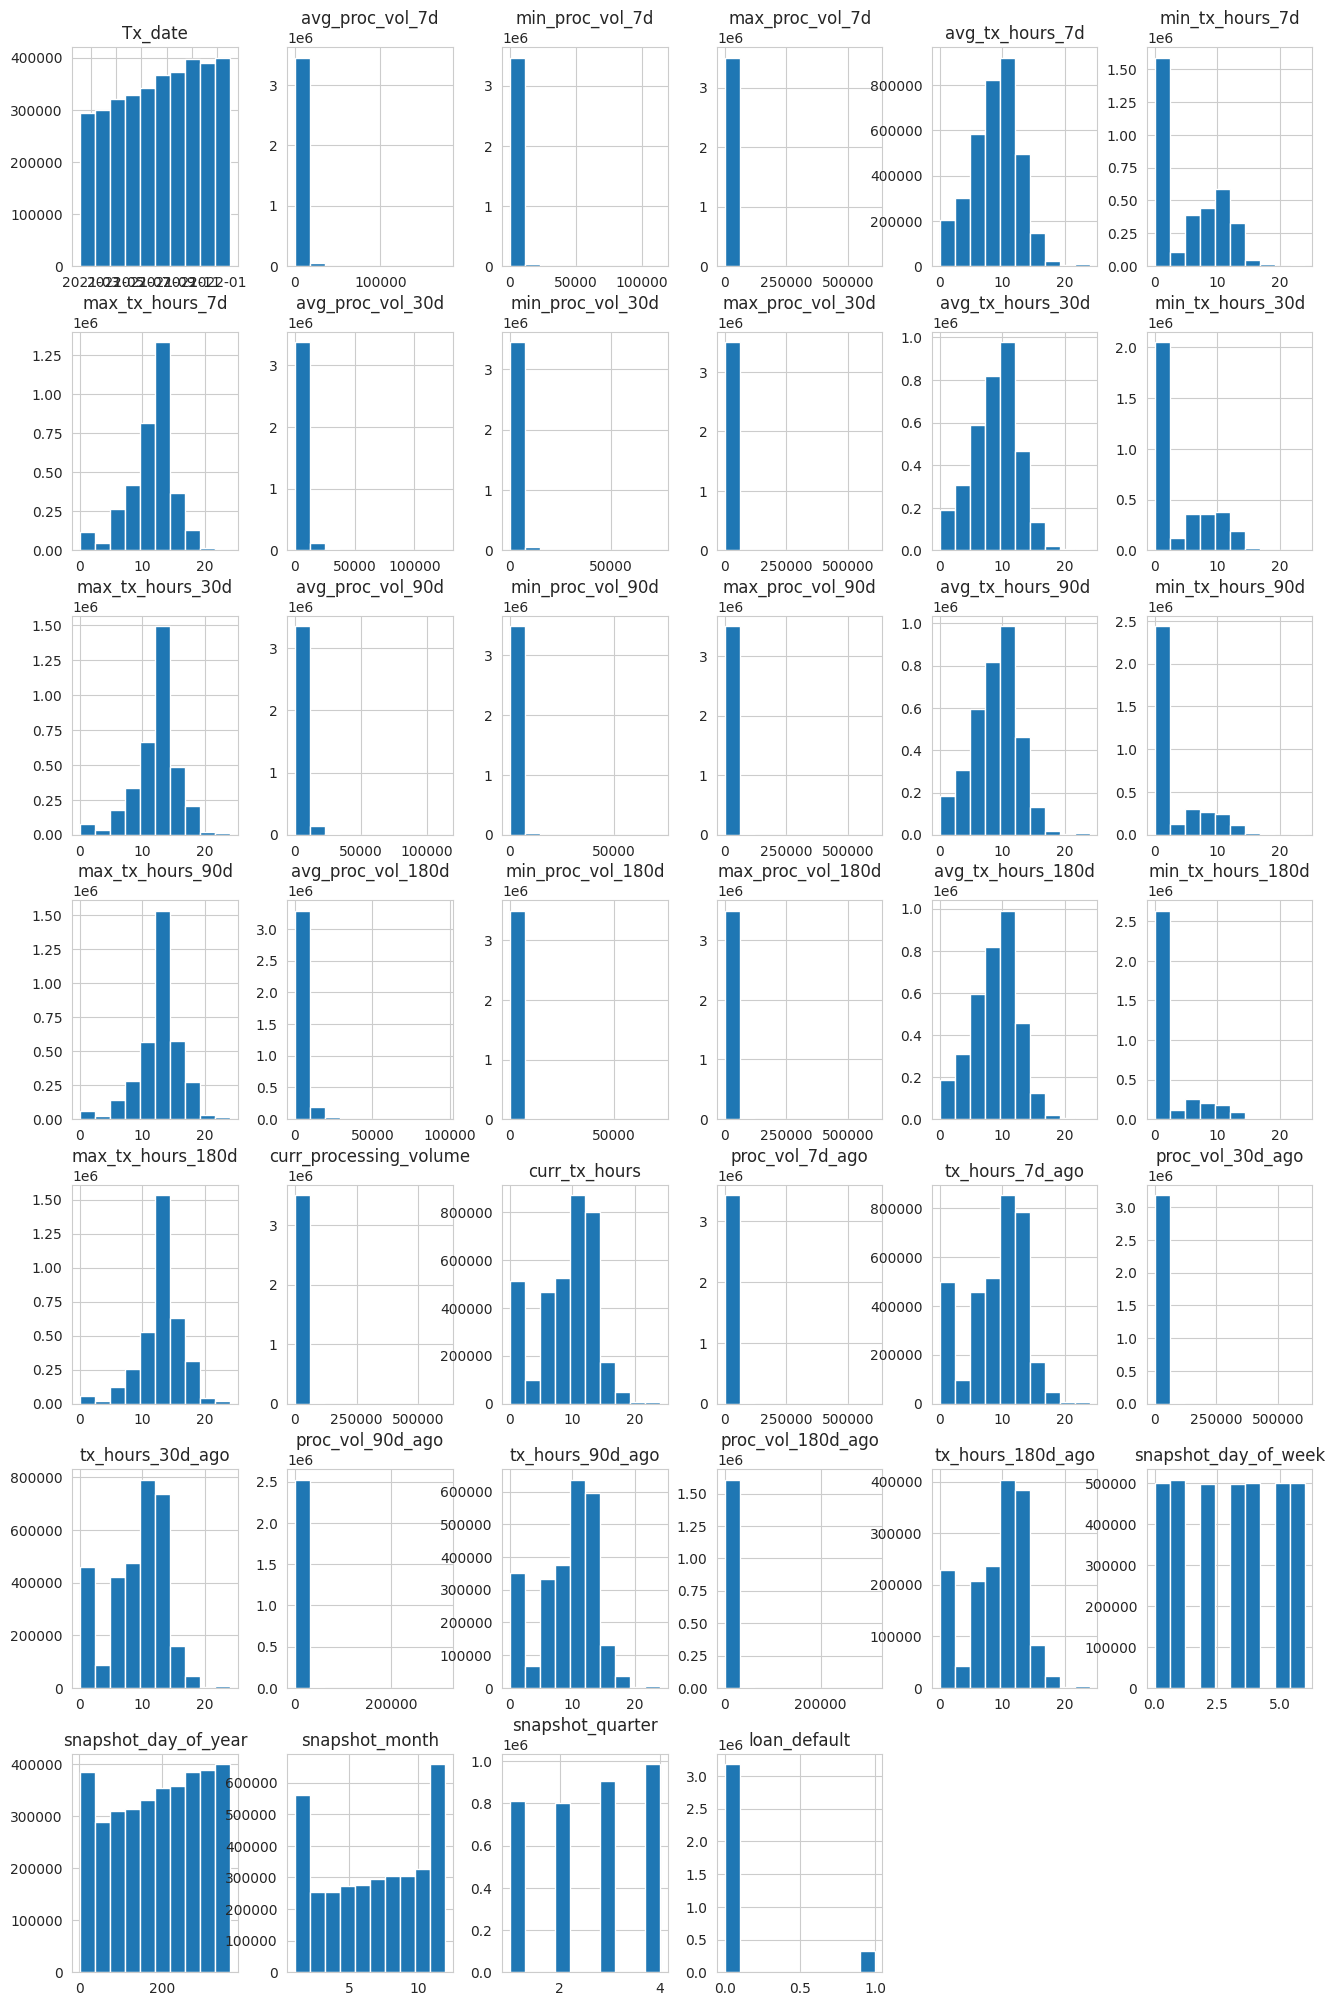

In [14]:
histogram = df_train_merged.hist(figsize=(16,25))

In [15]:
data = df_train_merged.copy()
y = data.loan_default
remove_list = ['loan_default']
X = data.drop(columns=remove_list)

X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=.25, random_state=42)
X_train.shape, X_test.shape

((2633009, 59), (877670, 59))

In [16]:
df_train = pd.merge(X_train,y_train,left_index=True,right_index=True,how='inner')
df_test = pd.merge(X_test,y_test,left_index=True,right_index=True,how='inner')

In [17]:
print('Not Default vs Default\n',df_train.loan_default.value_counts(dropna=False))
var = round(df_train.loan_default.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 loan_default
0.0    2387311
1.0     245698
Name: count, dtype: int64
The event rate is 9.33%


In [18]:
print('Not Default vs Default\n',df_test.loan_default.value_counts(dropna=False))
var = round(df_test.loan_default.value_counts(normalize=True,dropna=False).loc[1]*100,2)
print("The event rate is {}%".format(var))

Not Default vs Default
 loan_default
0.0    795771
1.0     81899
Name: count, dtype: int64
The event rate is 9.33%


In [19]:
df_train_merged.columns

Index(['Restaurant_ID', 'Tx_date', 'avg_proc_vol_7d', 'min_proc_vol_7d',
       'max_proc_vol_7d', 'avg_tx_hours_7d', 'min_tx_hours_7d',
       'max_tx_hours_7d', 'cv_proc_vol_7d', 'cv_tx_hours_7d',
       'avg_proc_vol_30d', 'min_proc_vol_30d', 'max_proc_vol_30d',
       'avg_tx_hours_30d', 'min_tx_hours_30d', 'max_tx_hours_30d',
       'cv_proc_vol_30d', 'cv_tx_hours_30d', 'avg_proc_vol_90d',
       'min_proc_vol_90d', 'max_proc_vol_90d', 'avg_tx_hours_90d',
       'min_tx_hours_90d', 'max_tx_hours_90d', 'cv_proc_vol_90d',
       'cv_tx_hours_90d', 'avg_proc_vol_180d', 'min_proc_vol_180d',
       'max_proc_vol_180d', 'avg_tx_hours_180d', 'min_tx_hours_180d',
       'max_tx_hours_180d', 'cv_proc_vol_180d', 'cv_tx_hours_180d',
       'curr_processing_volume', 'curr_tx_hours', 'proc_vol_7d_ago',
       'tx_hours_7d_ago', 'pct_change_proc_vol_vs_7d_ago',
       'pct_change_tx_hours_vs_7d_ago', 'proc_vol_30d_ago', 'tx_hours_30d_ago',
       'pct_change_proc_vol_vs_30d_ago', 'pct_change_tx

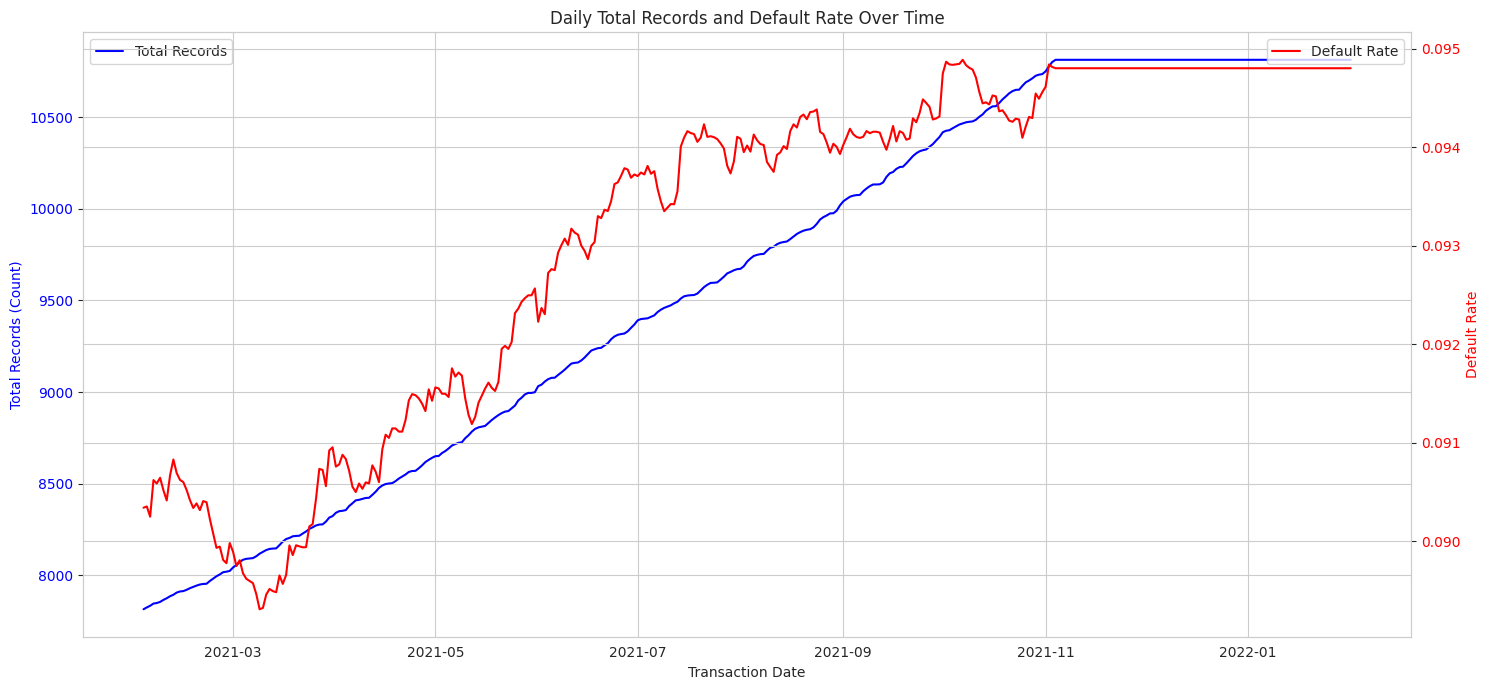

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Tx_date and calculate default rate and total count
df_daily_summary = df_train_merged.groupby('Tx_date').agg(
    total_defaults=('loan_default', 'sum'),
    total_records=('loan_default', 'count')
).reset_index()
df_daily_summary['default_rate'] = df_daily_summary['total_defaults'] / df_daily_summary['total_records']

# Create the plot
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot total records on the left y-axis
sns.lineplot(x='Tx_date', y='total_records', data=df_daily_summary, ax=ax1, color='blue', label='Total Records')
ax1.set_xlabel('Transaction Date')
ax1.set_ylabel('Total Records (Count)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for default rate
ax2 = ax1.twinx()
sns.lineplot(x='Tx_date', y='default_rate', data=df_daily_summary, ax=ax2, color='red', label='Default Rate')
ax2.set_ylabel('Default Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legend
plt.title('Daily Total Records and Default Rate Over Time')
fig.tight_layout() # Adjust layout to prevent overlapping elements
plt.show()

In [21]:
excel_file_path = folder_path + 'daily_default_summary.xlsx'
df_daily_summary.to_excel(excel_file_path, index=False)
print(f"Plot data exported to: {excel_file_path}")

Plot data exported to: /content/drive/My Drive/Colab Notebooks/RX_PD_Model/daily_default_summary.xlsx


In [22]:
#create a dictionary with feature name and type "numerical" or "categorical". This will be used by the optbinning process
feature_list = list(X.columns)
remove_list = ['Restaurant_ID','Tx_date']
feature_list = [x for x in feature_list if x not in remove_list]
feature_dict = {}
for feature in feature_list:
    feature_dict[feature] = str(X[feature].dtype)

for feature in feature_dict.keys():
    # print(feature, feature_type[feature])
    if feature_dict[feature] == 'float64' or feature_dict[feature] == 'int64' or feature_dict[feature] == 'int32':
        feature_dict[feature] = 'numerical'
    if feature_dict[feature] == 'object':
        feature_dict[feature] = 'categorical'
#Sort by having categorical features at the top.
feature_dict=dict(sorted(feature_dict.items(), key=lambda item: item[1]))

In [23]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2633009 entries, 2356825 to 2713050
Data columns (total 59 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   Restaurant_ID                    object        
 1   Tx_date                          datetime64[ns]
 2   avg_proc_vol_7d                  float64       
 3   min_proc_vol_7d                  float64       
 4   max_proc_vol_7d                  float64       
 5   avg_tx_hours_7d                  float64       
 6   min_tx_hours_7d                  float64       
 7   max_tx_hours_7d                  float64       
 8   cv_proc_vol_7d                   object        
 9   cv_tx_hours_7d                   object        
 10  avg_proc_vol_30d                 float64       
 11  min_proc_vol_30d                 float64       
 12  max_proc_vol_30d                 float64       
 13  avg_tx_hours_30d                 float64       
 14  min_tx_hours_30d                 

cv_proc_vol_7d IV = 10.803877


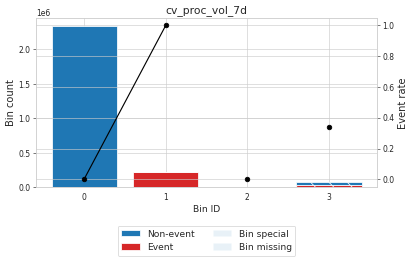

cv_tx_hours_7d IV = 2.868154


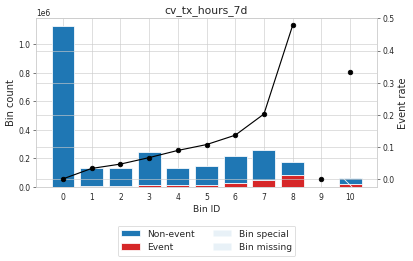

cv_proc_vol_30d IV = 13.363547


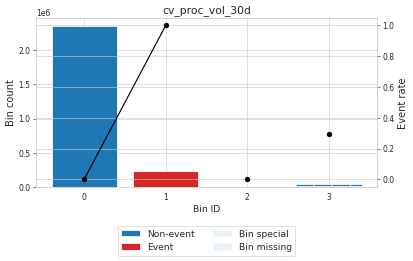

cv_tx_hours_30d IV = 5.333825


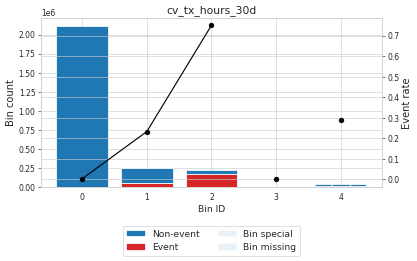

cv_proc_vol_90d IV = 14.151215


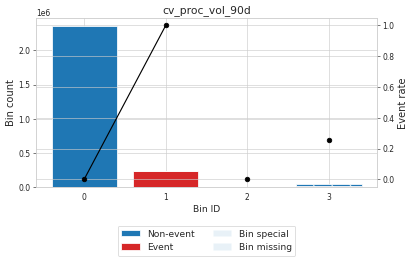

cv_tx_hours_90d IV = 7.060042


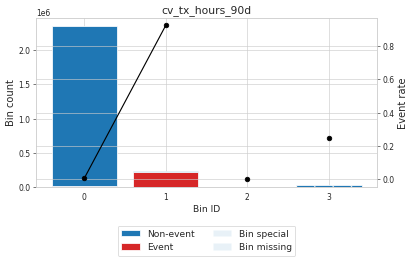

cv_proc_vol_180d IV = 14.28661


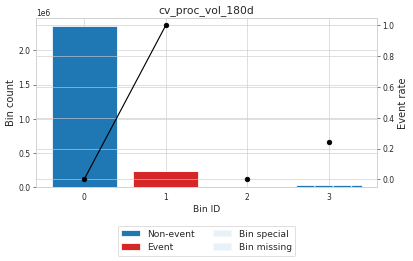

cv_tx_hours_180d IV = 8.990605


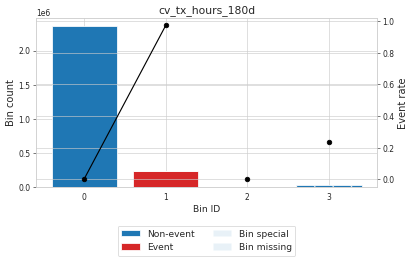

pct_change_proc_vol_vs_7d_ago IV = 10.149196


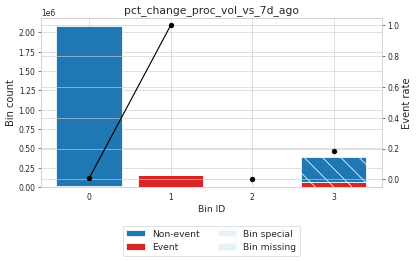

pct_change_tx_hours_vs_7d_ago IV = 0.263782


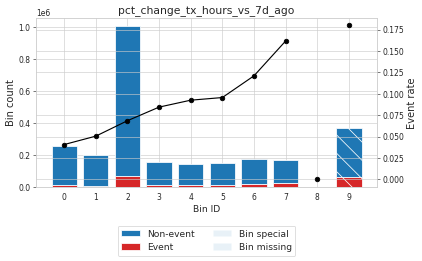

pct_change_proc_vol_vs_30d_ago IV = 14.312521


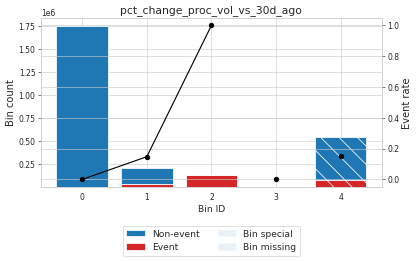

pct_change_tx_hours_vs_30d_ago IV = 0.232055


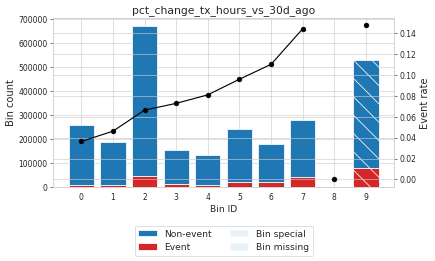

pct_change_proc_vol_vs_90d_ago IV = 5.752093


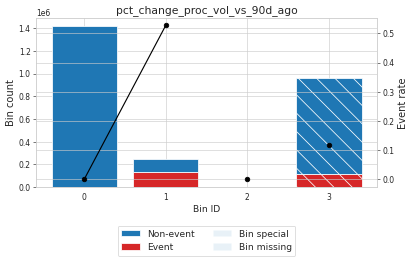

pct_change_tx_hours_vs_90d_ago IV = 0.175274


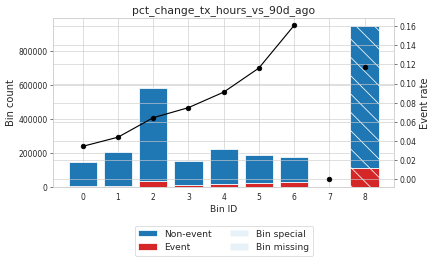

pct_change_proc_vol_vs_180d_ago IV = 3.870944


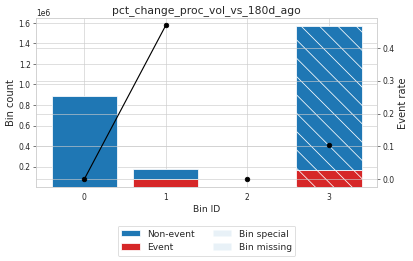

pct_change_tx_hours_vs_180d_ago IV = 0.112517


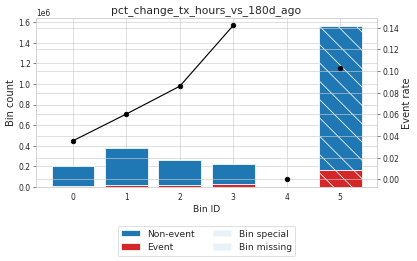

Ownership_type IV = 0.06036


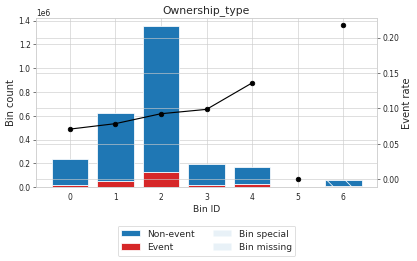

Restaurant_catagory IV = 0.042417


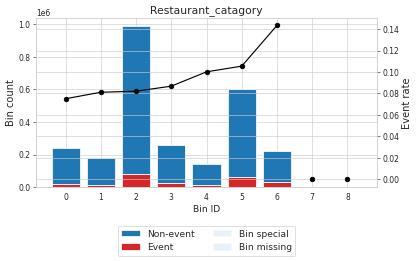

Market_segment IV = 0.045928


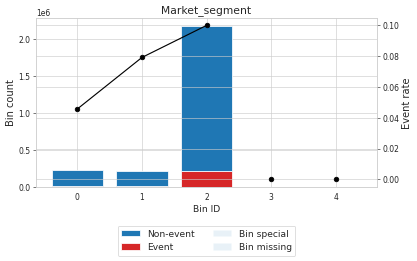

avg_proc_vol_7d IV = 0.720091


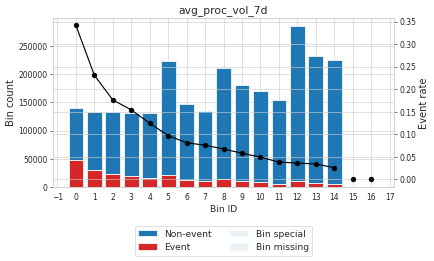

min_proc_vol_7d IV = 0.434758


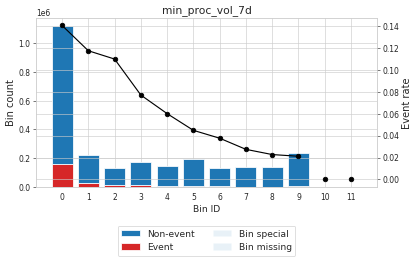

max_proc_vol_7d IV = 0.612587


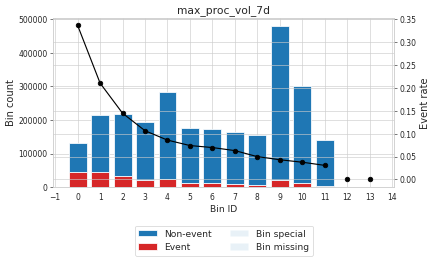

avg_tx_hours_7d IV = 0.498318


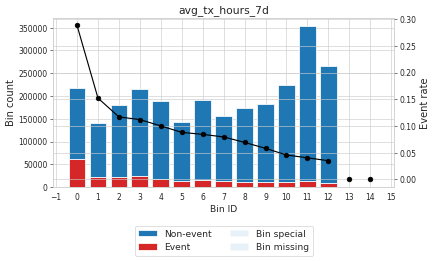

min_tx_hours_7d IV = 0.279453


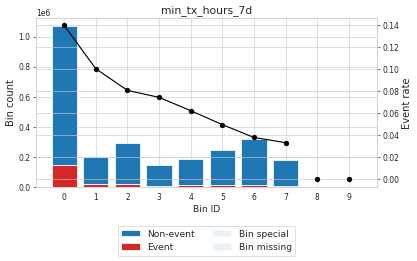

max_tx_hours_7d IV = 0.446084


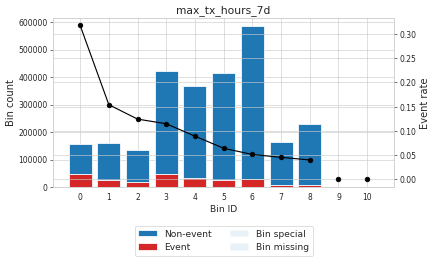

avg_proc_vol_30d IV = 0.719549


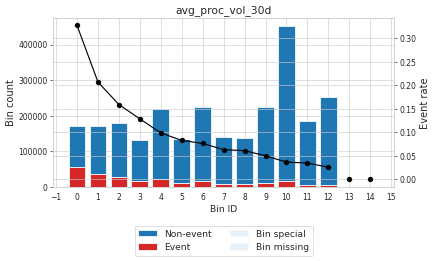

min_proc_vol_30d IV = 0.31473


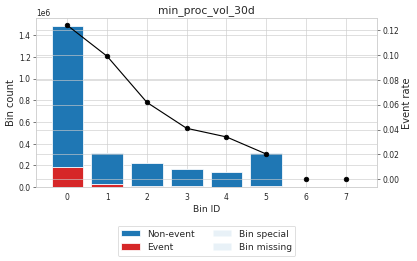

max_proc_vol_30d IV = 0.541357


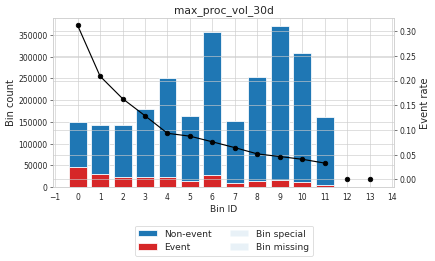

avg_tx_hours_30d IV = 0.512207


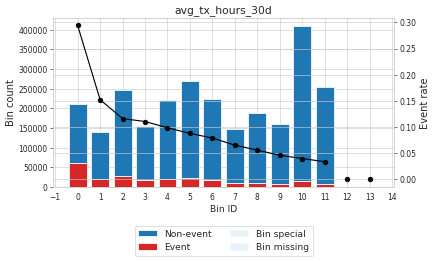

min_tx_hours_30d IV = 0.20369


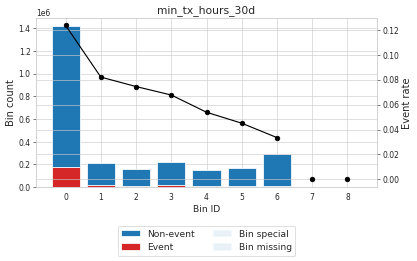

max_tx_hours_30d IV = 0.408928


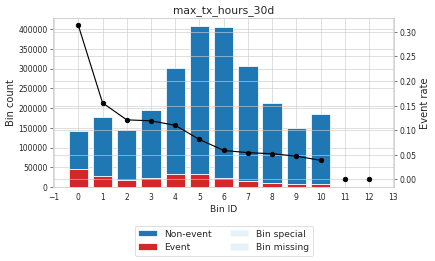

avg_proc_vol_90d IV = 0.695939


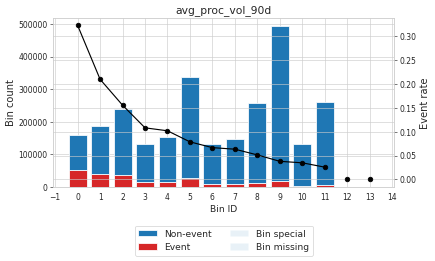

min_proc_vol_90d IV = 0.224696


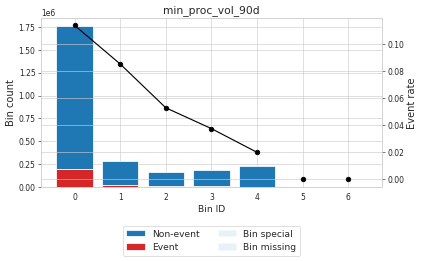

max_proc_vol_90d IV = 0.465598


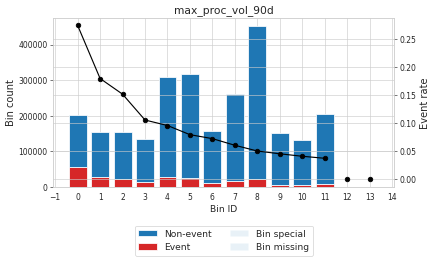

avg_tx_hours_90d IV = 0.505434


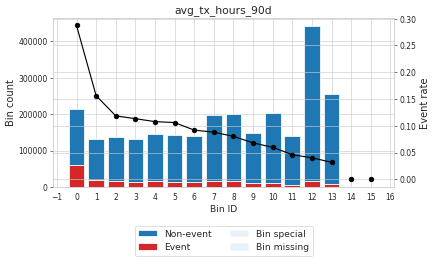

min_tx_hours_90d IV = 0.150378


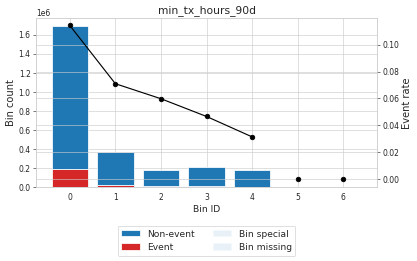

max_tx_hours_90d IV = 0.351583


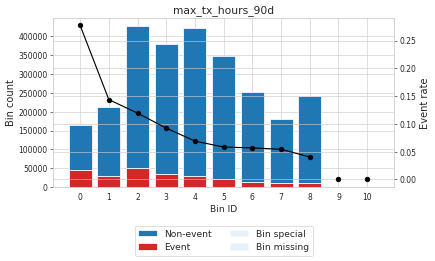

avg_proc_vol_180d IV = 0.675121


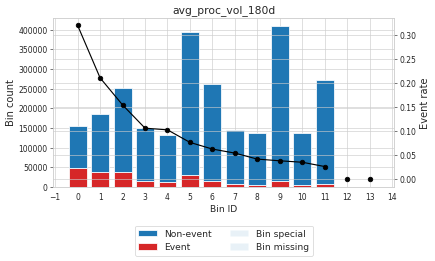

min_proc_vol_180d IV = 0.179072


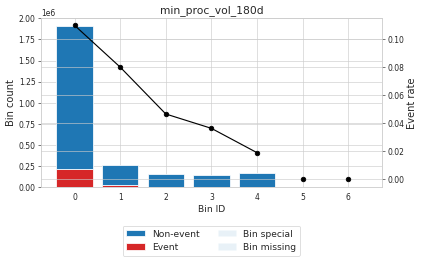

max_proc_vol_180d IV = 0.426951


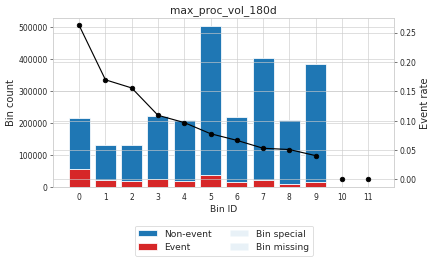

avg_tx_hours_180d IV = 0.492463


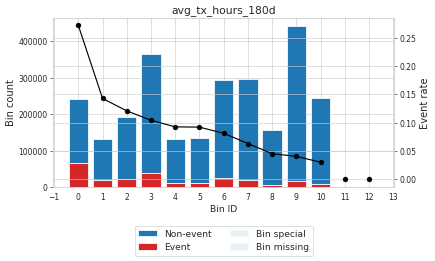

min_tx_hours_180d IV = 0.123668


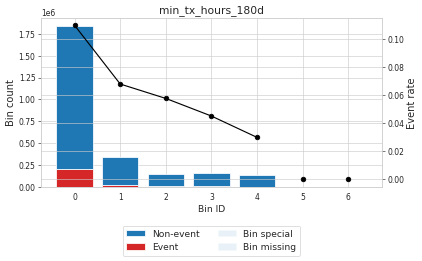

max_tx_hours_180d IV = 0.313165


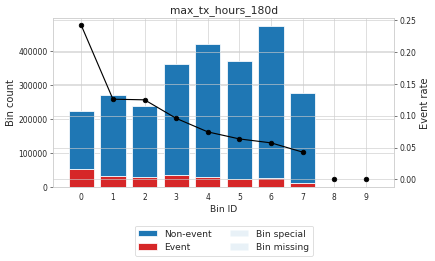

curr_processing_volume IV = 0.510561


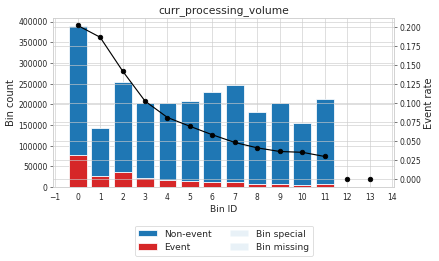

curr_tx_hours IV = 0.343676


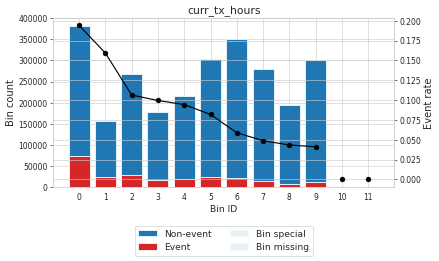

proc_vol_7d_ago IV = 0.494802


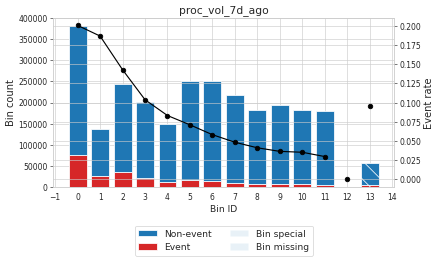

tx_hours_7d_ago IV = 0.331163


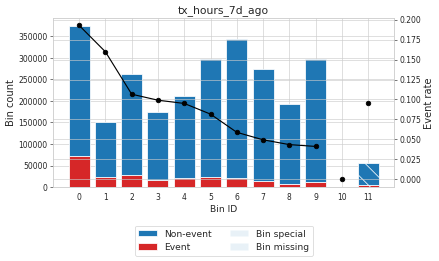

proc_vol_30d_ago IV = 0.447431


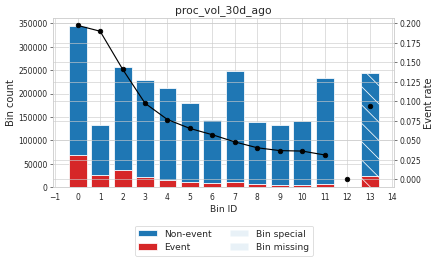

tx_hours_30d_ago IV = 0.296557


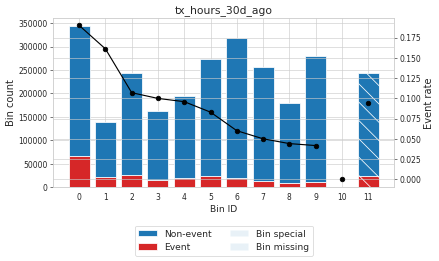

proc_vol_90d_ago IV = 0.346277


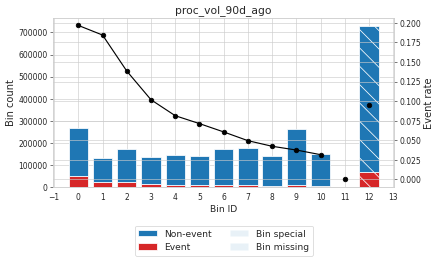

tx_hours_90d_ago IV = 0.229963


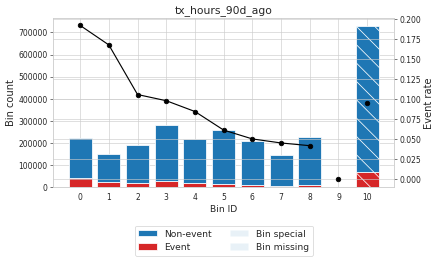

proc_vol_180d_ago IV = 0.207261


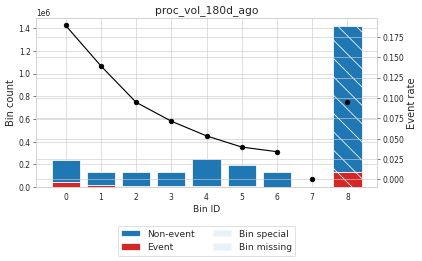

tx_hours_180d_ago IV = 0.139447


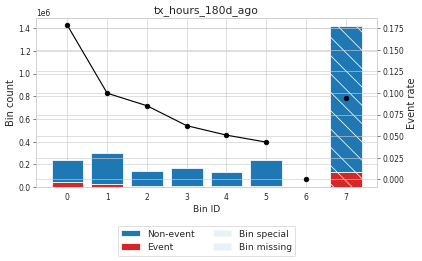

snapshot_day_of_week IV = 1e-06


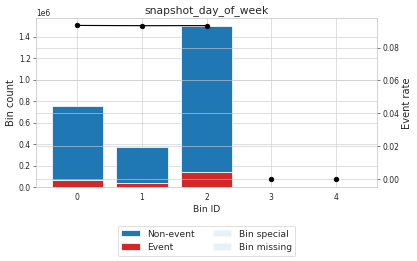

snapshot_day_of_year IV = 0.000457


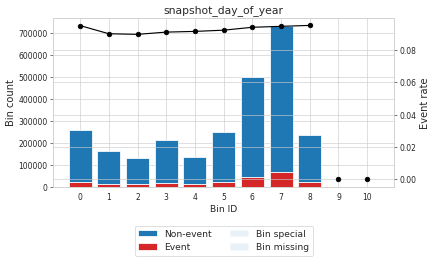

snapshot_month IV = 0.000431


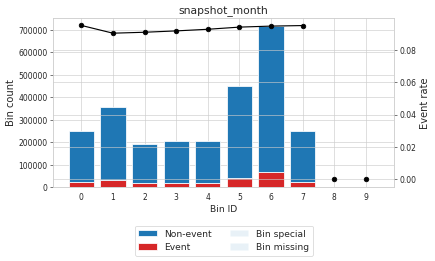

snapshot_quarter IV = 0.000227


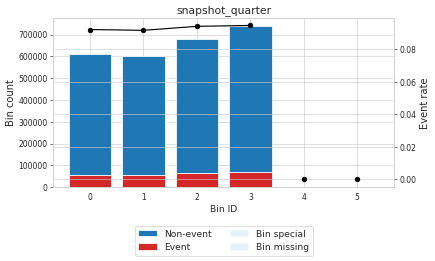

In [24]:
plt.rcParams['figure.figsize'] = [8, 4]
plt.rcParams['figure.dpi'] = 55 # 200 e.g. is really fine, but slower
bin_table = pd.DataFrame()
# feature_type = {'x1':"numerical"}
for feature in feature_dict:
    optb = OptimalBinning(name=feature, dtype=feature_dict[feature], solver="cp")
    optb.fit(X_train[feature], y_train)
    woe_var = feature + '_woe'
    # Add WoE variables to the data
    df_train[woe_var] = optb.transform(df_train[feature], metric="woe")
    df_test[woe_var] = optb.transform(df_test[feature], metric="woe")
    df_holdout_merged[woe_var] = optb.transform(df_holdout_merged[feature], metric="woe")

    binning_table = optb.binning_table
    table = binning_table.build()

    #Vizualize
    print(feature, "IV =", round(table.loc[['Totals']].IV[0],6))
    binning_table.plot(metric="event_rate",style='bin')

    table.reset_index(inplace=True)
    table['FeatureName'] = feature
    bin_table = pd.concat([bin_table, table])

bin_table=bin_table.reset_index()
bin_table.drop(columns='level_0',inplace=True)
bin_table.rename(columns = {'index':'Bin_Num'},inplace=True)

In [25]:
totals = bin_table[bin_table['Bin_Num'] == 'Totals']
totals.sort_values(by='IV', ascending=False, na_position='first',inplace=True)
totals[['FeatureName','IV']].to_excel('VariablesSummary.xlsx',index=False)
bin_table.to_excel('BinTable.xlsx',index=False)

In [ ]:
list_woe = [x for x in df_train.columns if x[-3:]=='woe']

clf = GradientBoostingClassifier(random_state=42)

grid = {
    "n_estimators": [40,50, 100, 200, 500], #The number of boosting stages to perform
    "max_leaf_nodes": [2, 5, 10, 20], # Grow trees with max_leaf_nodes in best-first fashion.
    "learning_rate": [0.01,0.1,0.5,1], #Learning rate shrinks the contribution of each tree by learning_rate
    "min_samples_leaf":[0.02,0.05], #The minimum number of samples required to be at a leaf node.
}

grid_search = HalvingGridSearchCV(estimator=clf, param_grid=grid, n_jobs=-1, cv=5, \
                                  scoring='roc_auc',error_score=0,random_state=42, refit=True)
grid_search.fit(df_train[list_woe], y_train)

shap_elimination = ShapRFECV(clf=grid_search, step=0.2, cv=5, scoring='roc_auc', n_jobs=-1)
report = shap_elimination.fit_compute(df_train[list_woe], y_train,check_additivity=False)
performance_plot = shap_elimination.plot()

In [ ]:
report[report['num_features']<20][['num_features', 'features_set', 'train_metric_mean','val_metric_mean']]

In [ ]:
requirements = ["optbinning", "probatus", "shap", "scikit-learn", "pandas", "numpy", "seaborn", "matplotlib", "openpyxl"]

with open('requirements.txt', 'w') as f:
    for lib in requirements:
        f.write(f"{lib}\n")

print("requirements.txt file has been created successfully.")